In [10]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from preprocessing import load_data, clean_data, create_time_features, calculate_metrics, segment_customers, prepare_ml_data, display_summary
from model import SalesPredictor
from utils import plot_sales_evolution, plot_profit_evolution, plot_pub_vs_sales

print('[OK] Imports OK')

[OK] Imports OK


In [11]:
DATA_PATH = os.path.join(os.getcwd(), '..', 'data', 'dataset.csv')
data = load_data(DATA_PATH)
data = clean_data(data)
data = create_time_features(data)
data = calculate_metrics(data)
data.head()

[OK] Dataset loaded: 10,000 rows, 16 columns
[OK] Cleaning done: 10,000 rows kept (0 removed)
[OK] Time features created
[OK] Business metrics calculated


,Transaction_ID,Date,Heure,Customer_ID,Categorie,Produit,Quantite,Prix_Unitaire,Cout_Unitaire,Reduction_%,...,Ville,Annee,Mois,Mois_Nom,Jour_Semaine,Jour_Semaine_Nom,CA,Marge_Brute,Marge_Nette,ROI_Pub_%
0,TXN_006245,2023-01-01,17:58,CUST_07165,Vetements,T-Shirt Coton,1,24.99,10.0,0,...,Nice,2023,1,January,6,Sunday,24.99,14.99,-154.01,-91.130178
1,TXN_000852,2023-01-01,08:10,CUST_03721,Vetements,Jean Slim,1,59.99,28.0,0,...,Nantes,2023,1,January,6,Sunday,59.99,31.99,-233.01,-87.928302
2,TXN_002388,2023-01-01,11:38,CUST_08238,Vetements,Echarpe Hiver,2,29.99,12.0,0,...,Madrid,2023,1,January,6,Sunday,59.98,35.98,-286.02,-88.826087
3,TXN_004283,2023-01-01,13:06,CUST_00802,Vetements,Ceinture Cuir,5,34.99,15.0,0,...,Bruxelles,2023,1,January,6,Sunday,174.95,99.95,-288.05,-74.239691
4,TXN_004321,2023-01-01,18:36,CUST_03216,Vetements,Jean Slim,1,59.99,28.0,15,...,Gand,2023,1,January,6,Sunday,50.99,22.99,-187.01,-89.052381


In [12]:
display_summary(data)


[STAT] BUSINESS SUMMARY
  [SHOP] Transactions      : 10,000
  [>>] Unique customers  : 6,277

  [EUR] Total revenue     :   502,970.20 €
  [STAT] Avg. revenue      :        50.30 €
  [REV] Total profit      : -2,834,333.80 €
  [UP] Total ad spend    : 3,114,998.50 €

  [ROI] Global ROI        :      -90.99 %


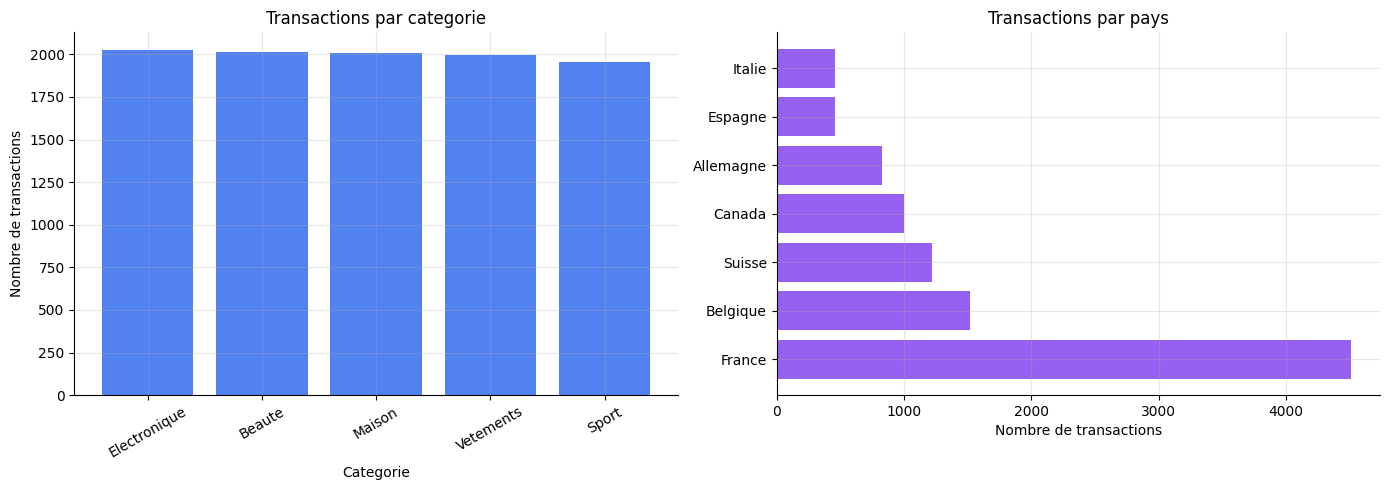

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par categorie
cat_counts = data["Categorie"].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color="#2563EB", alpha=0.8)
axes[0].set_title("Transactions par categorie")
axes[0].set_xlabel("Categorie")
axes[0].set_ylabel("Nombre de transactions")
axes[0].tick_params(axis="x", rotation=30)

# Par pays
pays_counts = data["Pays"].value_counts()
axes[1].barh(pays_counts.index, pays_counts.values, color="#7C3AED", alpha=0.8)
axes[1].set_title("Transactions par pays")
axes[1].set_xlabel("Nombre de transactions")

plt.tight_layout()
plt.show()

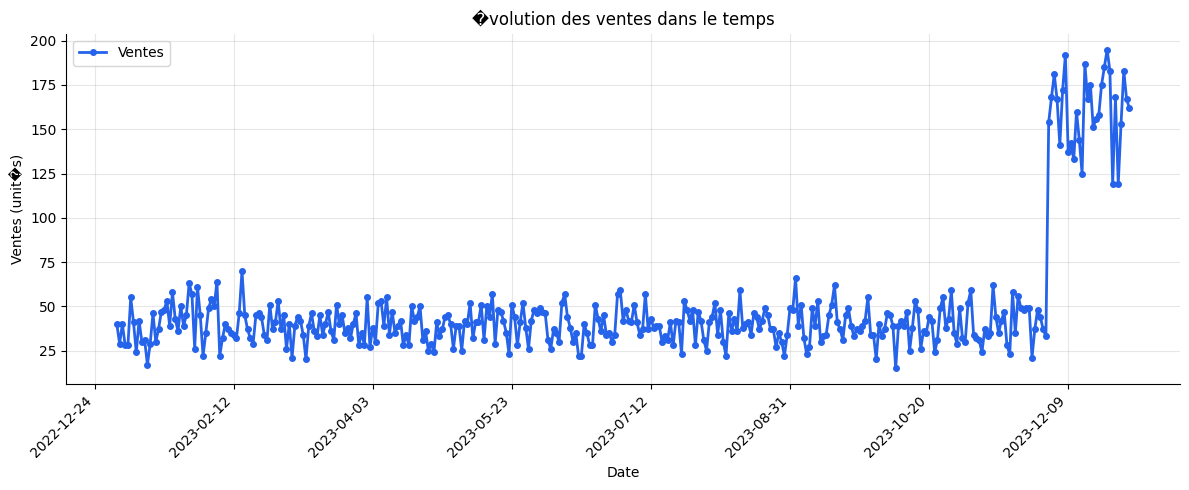

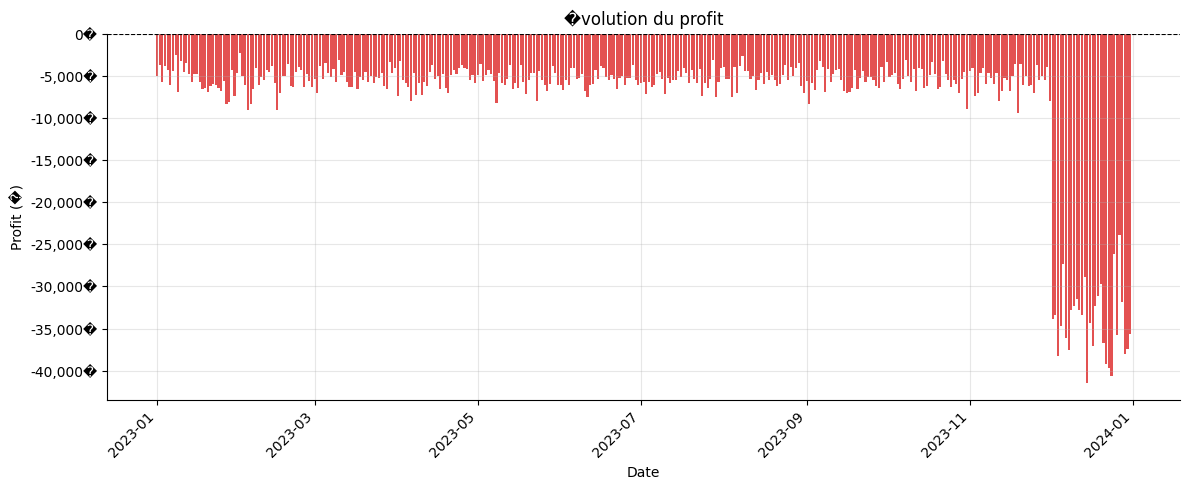

In [14]:
daily = data.groupby("Date").agg(Ventes=("Quantite", "sum"), Profit=("Profit", "sum")).reset_index()
plot_sales_evolution(daily)
plot_profit_evolution(daily)

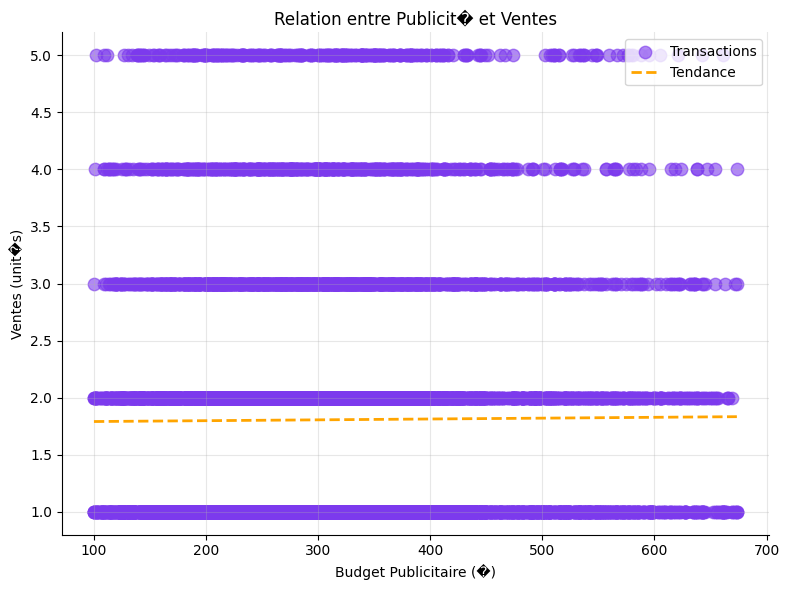

In [15]:
pub_data = data.rename(columns={"Budget_Pub": "Publicite", "Quantite": "Ventes"})
plot_pub_vs_sales(pub_data)


[>>] CUSTOMER SEGMENTATION
Segment
Occasionnel    3681
Regulier       2192
VIP             404


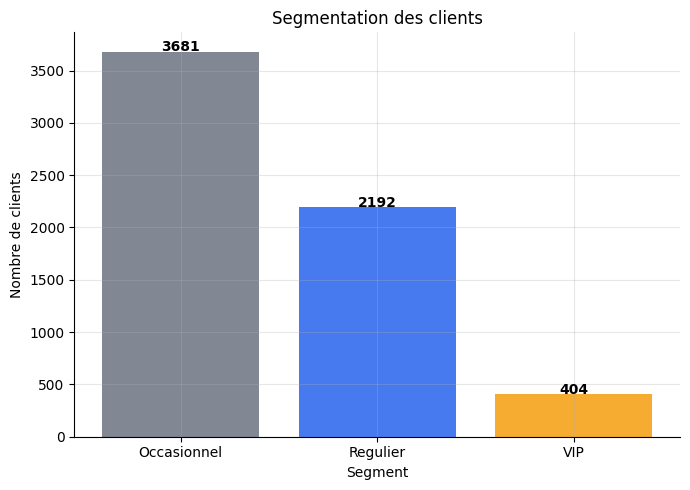

,Frequence,Montant_Total
Segment,,
Occasionnel,1.00,51.60
Regulier,2.23,100.58
VIP,3.55,229.09


In [16]:
customers = segment_customers(data)

seg_counts = customers["Segment"].value_counts()
colors = {"VIP": "#F59E0B", "Regulier": "#2563EB", "Occasionnel": "#6B7280"}
bar_colors = [colors.get(s, "gray") for s in seg_counts.index]

plt.figure(figsize=(7, 5))
plt.bar(seg_counts.index, seg_counts.values, color=bar_colors, alpha=0.85)
plt.title("Segmentation des clients")
plt.xlabel("Segment")
plt.ylabel("Nombre de clients")
for i, v in enumerate(seg_counts.values):
    plt.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

customers.groupby("Segment")[["Frequence", "Montant_Total"]].mean().round(2)

In [17]:
X, y, feature_names = prepare_ml_data(data)
predictor = SalesPredictor()
r2, mse = predictor.train(X, y, feature_names=feature_names)

print("
Coefficients:", predictor.get_coefficients())

SyntaxError: unterminated string literal (detected at line 5) (3220700273.py, line 5)

In [ ]:
budgets = [100, 200, 300, 400, 500]
predictions = [predictor.predict(b) for b in budgets]
profits = [round(p - b, 2) for b, p in zip(budgets, predictions)]

results = pd.DataFrame({
    "Budget_Pub (EUR)": budgets,
    "CA_Predit (EUR)": [round(p, 2) for p in predictions],
    "Profit_Estime (EUR)": profits
})
print(results.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(budgets, predictions, marker="o", color="#2563EB", linewidth=2, label="CA predit")
plt.plot(budgets, profits, marker="s", color="#16A34A", linewidth=2, linestyle="--", label="Profit estime")
plt.axhline(0, color="black", linewidth=0.8, linestyle=":")
plt.xlabel("Budget Publicitaire (EUR)")
plt.ylabel("EUR")
plt.title("Predictions du modele")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'predictor' is not defined